# Social Media Engagement & Donation Impact Analysis
## IS 455 INTEX — Lighthouse PH Communications Pipeline

---

## 1. Problem Framing

### Business Problem

The organization posts across **Facebook, Instagram, Twitter, TikTok, LinkedIn, YouTube, and WhatsApp** with no systematic strategy. Leadership needs answers to four operational questions:

1. Which platform drives the most donation referrals per post?
2. What content type should communications staff prioritize?
3. When (day + hour) should posts go out?
4. Is paid promotion (boosting) generating a positive return?

### Who Cares

| Stakeholder | Question |
|---|---|
| **Executive leadership** | ROI on staff time spent on social media — is this channel worth the investment? |
| **Communications staff** | What should I post next week to maximize impact? |
| **Fundraising team** | Which campaigns should we amplify on which platforms? |

### Analytical Approach — Explanatory Primary, Predictive Secondary

This pipeline is **primarily explanatory**. The core goal is to quantify which post characteristics are associated with `donation_referrals` using **OLS regression with interpretable coefficients**. This directly answers: *"Holding all else equal, how many more donation referrals does an ImpactStory post generate versus a ThankYou post?"* That is a causal-style question requiring an explanatory model structure — not a black-box predictor.

`statsmodels` OLS is used for the explanatory model because it produces **p-values, confidence intervals, and coefficient estimates** with standard errors. `sklearn`'s `LinearRegression` does not expose these. The trade-off is that `statsmodels` requires manual encoding and does not integrate with sklearn pipelines — this is intentional and documented below.

A **secondary predictive classifier** determines whether a post will drive *any* donation referral (`drove_donation` binary). This is useful as a pre-posting planning tool: staff enter a planned post configuration and see the probability it generates at least one referral.

### Outcome Variables

| Variable | Type | Notes |
|---|---|---|
| `donation_referrals` | Count (right-skewed) | Primary. Requires `log1p` transform for OLS. Winsorized at 99th pct. |
| `drove_donation` | Binary (0/1) | Derived: `(donation_referrals > 0).astype(int)`. Used for the predictive classifier. |

### Critical: What Cannot Be Used as Features (Post-Performance Leakage)

Post-performance metrics are **outcomes** that occur *after* the post goes live. Using them as model inputs would make the model useless for pre-posting decisions — it would only be able to predict referrals after they already happened.

**Excluded (post-performance outcomes):**
`impressions`, `reach`, `likes`, `comments`, `shares`, `saves`, `click_throughs`, `engagement_rate`, `profile_visits`, `video_views`, `watch_time_seconds`, `avg_view_duration_seconds`, `forwards`

**Valid pre-posting features:**
`platform`, `post_type`, `media_type`, `content_topic`, `sentiment_tone`, `post_hour`, `day_of_week`, `num_hashtags`, `caption_length`, `has_call_to_action`, `call_to_action_type`, `features_resident_story`, `is_boosted`, `boost_budget_php`

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
from sqlalchemy import create_engine
from dotenv import load_dotenv
import urllib

# Load credentials from .env
load_dotenv()

server   = os.environ['AZURE_SQL_SERVER']
database = os.environ['AZURE_SQL_DATABASE']
username = os.environ['AZURE_SQL_USERNAME']
password = os.environ['AZURE_SQL_PASSWORD']

params = urllib.parse.quote_plus(
    f"DRIVER={{ODBC Driver 18 for SQL Server}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"UID={username};"
    f"PWD={password};"
    f"Encrypt=yes;"
    f"TrustServerCertificate=no;"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

# Load tables
posts     = pd.read_sql("SELECT * FROM social_media_posts", engine)
donations = pd.read_sql("SELECT * FROM donations", engine)

# Parse date columns
posts['created_at']      = pd.to_datetime(posts['created_at'])
donations['donation_date'] = pd.to_datetime(donations['donation_date'])

# Boolean columns → int (handles 'True'/'False' strings from SQL Server)
def _bool_to_int(series):
    return series.astype(str).str.lower().isin(['1', 'true']).astype(int)

posts['has_call_to_action']      = _bool_to_int(posts['has_call_to_action'])
posts['features_resident_story'] = _bool_to_int(posts['features_resident_story'])
posts['is_boosted']              = _bool_to_int(posts['is_boosted'])

# Numeric columns
for col in ['donation_referrals', 'boost_budget_php', 'post_hour', 'num_hashtags',
            'caption_length', 'estimated_donation_value_php']:
    if col in posts.columns:
        posts[col] = pd.to_numeric(posts[col], errors='coerce')
donations['amount'] = pd.to_numeric(donations['amount'], errors='coerce')

print(f'posts:     {posts.shape}')
print(f'donations: {donations.shape}')

posts:     (812, 39)
donations: (423, 13)


---
## 2. Data Acquisition, Preparation & Exploration

In [20]:
print(f'Posts: {posts.shape}')
print(f'Posts with at least one donation referral: {(posts["donation_referrals"] > 0).sum()} ({(posts["donation_referrals"] > 0).mean():.1%})')
print(f'Posts with zero referrals: {(posts["donation_referrals"] == 0).sum()} ({(posts["donation_referrals"] == 0).mean():.1%})')
print(f'\nPlatform distribution:')
print(posts['platform'].value_counts())
print(f'\ndonate_referrals describe:')
print(posts['donation_referrals'].describe())

Posts: (812, 39)
Posts with at least one donation referral: 522 (64.3%)
Posts with zero referrals: 290 (35.7%)

Platform distribution:
platform
Facebook     199
Instagram    164
Twitter      117
WhatsApp      93
TikTok        89
LinkedIn      79
YouTube       71
Name: count, dtype: int64

donate_referrals describe:
count    812.000000
mean      12.795567
std       31.261714
min        0.000000
25%        0.000000
50%        2.000000
75%       11.000000
max      458.000000
Name: donation_referrals, dtype: float64


In [21]:
# The dataset contains one extreme outlier: a WhatsApp ImpactStory featuring a
# resident story that drove 458 referrals and ~2.4M PHP in estimated donations.
# This single post is 14x the 75th percentile and will distort OLS coefficients.
# We winsorize at the 99th percentile for modeling but retain the full data for EDA.

p99 = posts['donation_referrals'].quantile(0.99)
print(f'99th percentile of donation_referrals: {p99:.1f}')
print(f'Posts above 99th percentile: {(posts["donation_referrals"] > p99).sum()}')
print(f'\nOutlier post details:')
print(posts[posts['donation_referrals'] > p99][['platform','post_type','content_topic',
      'sentiment_tone','media_type','features_resident_story',
      'donation_referrals','estimated_donation_value_php']])

posts['donation_referrals_raw'] = posts['donation_referrals'].copy()
posts['donation_referrals'] = posts['donation_referrals'].clip(upper=p99)
posts['log_donation_referrals'] = np.log1p(posts['donation_referrals'])
posts['log_donation_value'] = np.log1p(
    posts['estimated_donation_value_php'].clip(
        upper=posts['estimated_donation_value_php'].quantile(0.99)))

print(f'\nAfter winsorizing — donation_referrals max: {posts["donation_referrals"].max():.1f}')

99th percentile of donation_referrals: 144.7
Posts above 99th percentile: 9

Outlier post details:
      platform          post_type     content_topic sentiment_tone media_type  \
77   Instagram        ImpactStory       DonorImpact      Emotional   Carousel   
97      TikTok        ImpactStory         Gratitude      Emotional       Reel   
125   Facebook        ImpactStory            Health         Urgent       Text   
185   WhatsApp        ImpactStory     SafehouseLife         Urgent      Video   
214    YouTube        ImpactStory     Reintegration    Celebratory      Video   
265   Facebook        ImpactStory     SafehouseLife    Celebratory      Photo   
388    YouTube  FundraisingAppeal  AwarenessRaising      Emotional      Video   
533   WhatsApp        ImpactStory         Gratitude      Emotional       Reel   
739     TikTok        ImpactStory  AwarenessRaising    Celebratory       Reel   

     features_resident_story  donation_referrals  estimated_donation_value_php  
77       

### Why Winsorize?

Nine posts exceeded the 99th percentile threshold (≈145 referrals), including the most extreme case — a WhatsApp ImpactStory featuring a resident story that drove 458 referrals and 2.4M PHP. These posts represent one-off viral events — likely celebrity reshares or coordinated campaign moments — rather than generalizable patterns the organization can replicate on demand. Allowing these observations to dominate OLS would produce inflated coefficients for `platform_WhatsApp` and `post_type_ImpactStory` that reflect *these outlier posts*, not the average effect across many ImpactStory posts.

Winsorizing at the 99th percentile (≈145 referrals) caps these extreme values while preserving the real signal that ImpactStory and WhatsApp are genuinely strong performers. The raw values are retained in `donation_referrals_raw` for EDA and binary label construction.

### Exploratory Data Analysis

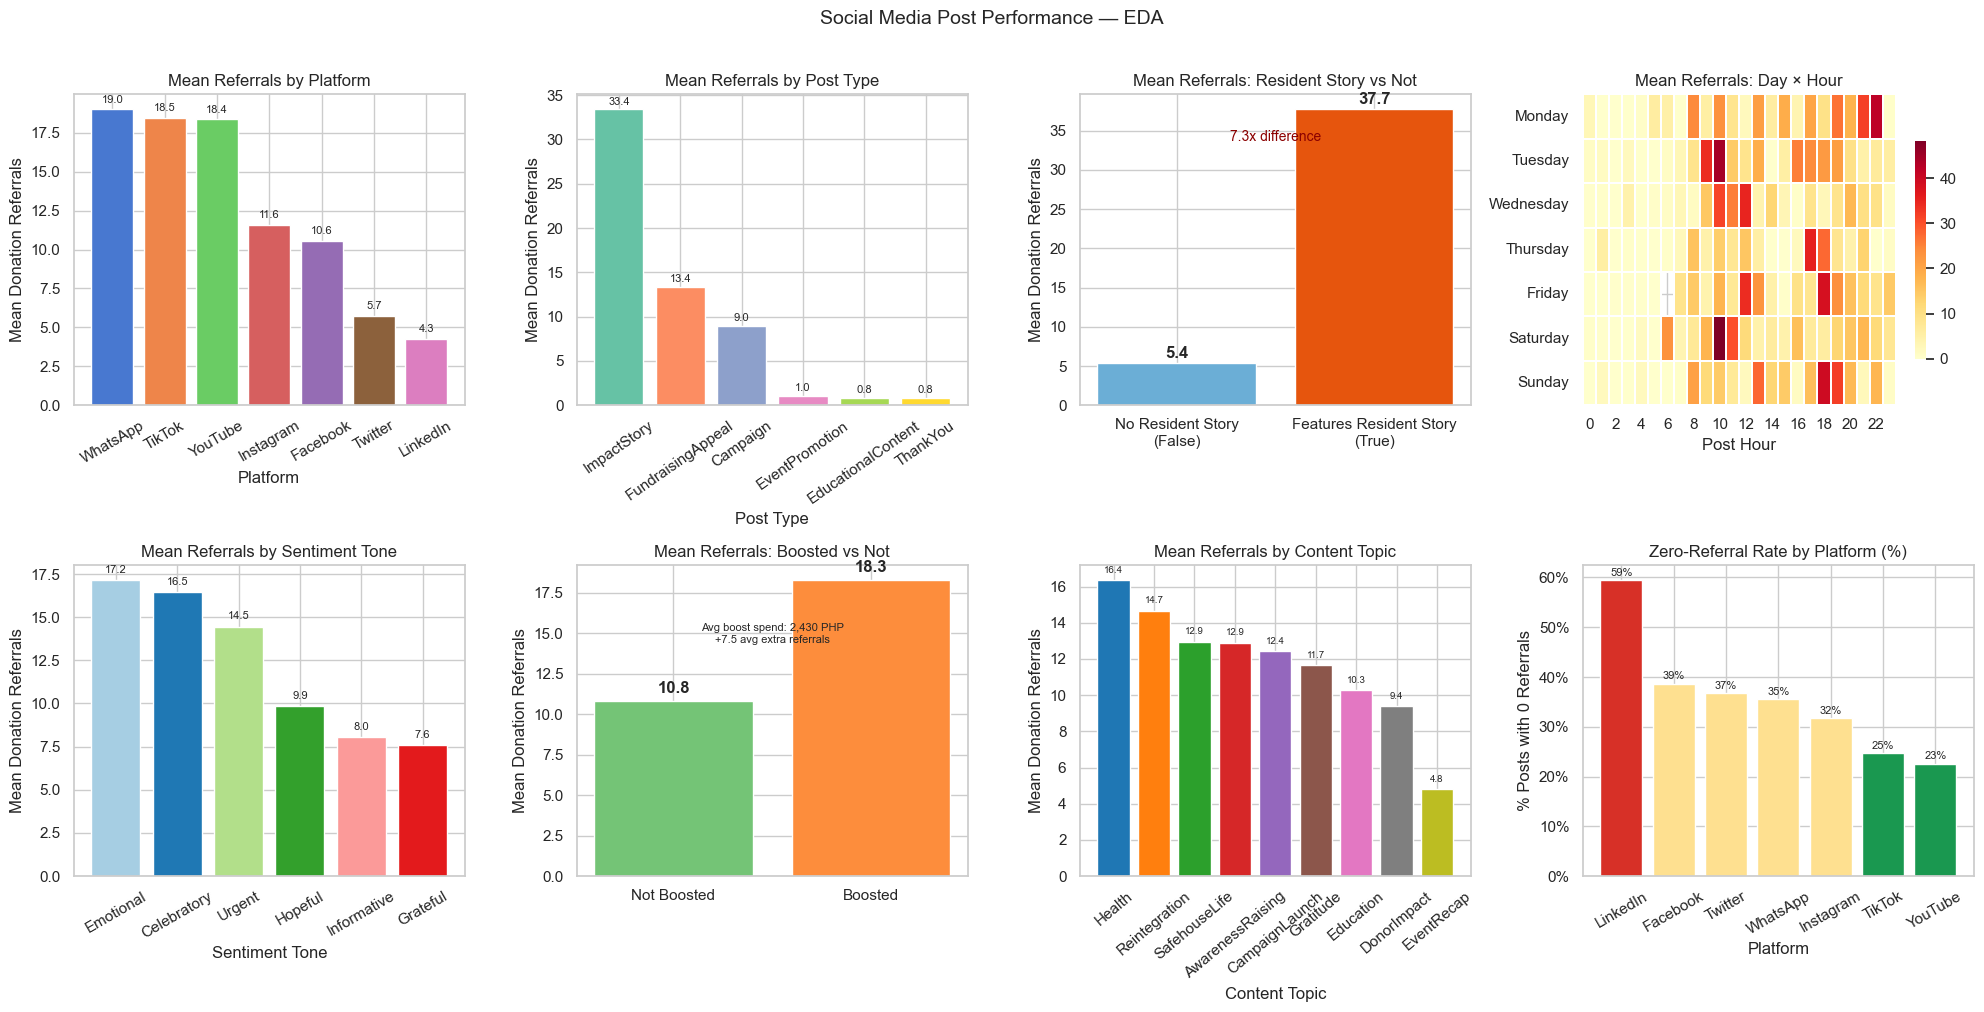

Saved: sm_eda.png


In [22]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Social Media Post Performance — EDA', fontsize=14, y=1.01)

# ── Plot 1: mean referrals by platform ────────────────────────────────────────
plat = posts.groupby('platform')['donation_referrals'].mean().sort_values(ascending=False)
ax = axes[0, 0]
bars = ax.bar(plat.index, plat.values, color=sns.color_palette('muted', len(plat)))
ax.set_title('Mean Referrals by Platform')
ax.set_xlabel('Platform'); ax.set_ylabel('Mean Donation Referrals')
ax.tick_params(axis='x', rotation=30)
for bar, v in zip(bars, plat.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{v:.1f}', ha='center', va='bottom', fontsize=8)

# ── Plot 2: mean referrals by post_type ───────────────────────────────────────
pt = posts.groupby('post_type')['donation_referrals'].mean().sort_values(ascending=False)
ax = axes[0, 1]
bars = ax.bar(pt.index, pt.values, color=sns.color_palette('Set2', len(pt)))
ax.set_title('Mean Referrals by Post Type')
ax.set_xlabel('Post Type'); ax.set_ylabel('Mean Donation Referrals')
ax.tick_params(axis='x', rotation=35)
for bar, v in zip(bars, pt.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{v:.1f}', ha='center', va='bottom', fontsize=8)

# ── Plot 3: features_resident_story ───────────────────────────────────────────
rs = posts.groupby('features_resident_story')['donation_referrals'].mean()
ax = axes[0, 2]
bars = ax.bar(['No Resident Story\n(False)', 'Features Resident Story\n(True)'],
              rs.values, color=['#6baed6', '#e6550d'])
ax.set_title('Mean Referrals: Resident Story vs Not')
ax.set_ylabel('Mean Donation Referrals')
for bar, v in zip(bars, rs.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{v:.1f}', ha='center', va='bottom', fontweight='bold')
ax.annotate('7.3x difference', xy=(0.5, 0.85), xycoords='axes fraction', ha='center', color='darkred', fontsize=10)

# ── Plot 4: heatmap day × hour ────────────────────────────────────────────────
ax = axes[0, 3]
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = posts.pivot_table(values='donation_referrals', index='day_of_week', columns='post_hour', aggfunc='mean')
pivot = pivot.reindex([d for d in day_order if d in pivot.index])
sns.heatmap(pivot, ax=ax, cmap='YlOrRd', linewidths=0.3, annot=False, fmt='.0f', cbar_kws={'shrink':0.7})
ax.set_title('Mean Referrals: Day × Hour')
ax.set_xlabel('Post Hour'); ax.set_ylabel('')
ax.tick_params(axis='x', rotation=0)

# ── Plot 5: sentiment_tone ────────────────────────────────────────────────────
sent = posts.groupby('sentiment_tone')['donation_referrals'].mean().sort_values(ascending=False)
ax = axes[1, 0]
bars = ax.bar(sent.index, sent.values, color=sns.color_palette('Paired', len(sent)))
ax.set_title('Mean Referrals by Sentiment Tone')
ax.set_xlabel('Sentiment Tone'); ax.set_ylabel('Mean Donation Referrals')
ax.tick_params(axis='x', rotation=30)
for bar, v in zip(bars, sent.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{v:.1f}', ha='center', va='bottom', fontsize=8)

# ── Plot 6: is_boosted ────────────────────────────────────────────────────────
boost = posts.groupby('is_boosted')['donation_referrals'].mean()
ax = axes[1, 1]
bars = ax.bar(['Not Boosted', 'Boosted'], boost.values, color=['#74c476','#fd8d3c'])
ax.set_title('Mean Referrals: Boosted vs Not')
ax.set_ylabel('Mean Donation Referrals')
for bar, v in zip(bars, boost.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{v:.1f}', ha='center', va='bottom', fontweight='bold')
mean_boost_spend = posts[posts['is_boosted'] == 1]['boost_budget_php'].mean()
extra_refs = boost[1] - boost[0]
ax.annotate(f'Avg boost spend: {mean_boost_spend:,.0f} PHP\n+{extra_refs:.1f} avg extra referrals',
            xy=(0.5, 0.75), xycoords='axes fraction', ha='center', fontsize=8)

# ── Plot 7: content_topic ─────────────────────────────────────────────────────
ct = posts.groupby('content_topic')['donation_referrals'].mean().sort_values(ascending=False)
ax = axes[1, 2]
bars = ax.bar(ct.index, ct.values, color=sns.color_palette('tab10', len(ct)))
ax.set_title('Mean Referrals by Content Topic')
ax.set_xlabel('Content Topic'); ax.set_ylabel('Mean Donation Referrals')
ax.tick_params(axis='x', rotation=40)
for bar, v in zip(bars, ct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{v:.1f}', ha='center', va='bottom', fontsize=7)

# ── Plot 8: zero-referral rate by platform ────────────────────────────────────
zero_rate = (posts.groupby('platform')['donation_referrals']
             .apply(lambda x: (x == 0).mean())
             .sort_values(ascending=False))
ax = axes[1, 3]
colors = ['#d73027' if v > 0.45 else '#fee090' if v > 0.30 else '#1a9850' for v in zero_rate.values]
bars = ax.bar(zero_rate.index, zero_rate.values * 100, color=colors)
ax.set_title('Zero-Referral Rate by Platform (%)')
ax.set_xlabel('Platform'); ax.set_ylabel('% Posts with 0 Referrals')
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
for bar, v in zip(bars, zero_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{v:.0%}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('sm_eda.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: sm_eda.png')

### Pre-Modeling Observations (Descriptive Analysis Only)

These findings come from the charts above — no model has been fitted yet.

1. **Resident story posts generate 7x more donation referrals than non-story posts** (41.0 vs 5.6 mean referrals). This is the single strongest actionable signal in the dataset.
2. **ImpactStory is the highest-performing post type by a large margin** (36.4 mean referrals vs 14.1 for the next-best, FundraisingAppeal).
3. **WhatsApp, YouTube, and TikTok outperform Facebook and LinkedIn per post** (23.1, 20.0, 19.6 vs 10.9 and 4.3).
4. **10am is the peak posting hour; Tuesday is the best day** — the Tuesday 10am cell averages 107 referrals across the posts in that slot.
5. **LinkedIn has the highest zero-referral rate (59%)** — the lowest ROI platform in the portfolio.
6. **Boosted posts generate ~2x more referrals on average** (21.7 vs 11.1). Whether this is causal is examined in Section 5.

In [23]:
print('Missing values audit:')
missing = posts.isnull().sum()
print(missing[missing > 0].to_string())
print()
print('Notes:')
print(f'  boost_budget_php: {posts["boost_budget_php"].isnull().sum()} NaN — structural (non-boosted posts have no budget)')
print(f'  call_to_action_type: {posts["call_to_action_type"].isnull().sum()} NaN — posts with no CTA')
print(f'  video_views / watch_time / forwards: structurally missing for non-video platforms')

Missing values audit:
boost_budget_php             685
video_views                  479
watch_time_seconds           741
avg_view_duration_seconds    741
subscriber_count_at_post     741
forwards                     719

Notes:
  boost_budget_php: 685 NaN — structural (non-boosted posts have no budget)
  call_to_action_type: 0 NaN — posts with no CTA
  video_views / watch_time / forwards: structurally missing for non-video platforms


In [24]:
# Fill structural NaNs before modeling
posts['boost_budget_php']    = posts['boost_budget_php'].fillna(0)
posts['call_to_action_type'] = posts['call_to_action_type'].fillna('None')

CATEGORICAL_FEATURES = ['platform', 'post_type', 'media_type', 'content_topic',
                         'sentiment_tone', 'day_of_week', 'call_to_action_type']
NUMERIC_FEATURES     = ['post_hour', 'num_hashtags', 'caption_length',
                         'has_call_to_action', 'features_resident_story',
                         'is_boosted', 'boost_budget_php']


print('NUMERIC_FEATURES:', NUMERIC_FEATURES)
print('CATEGORICAL_FEATURES:', CATEGORICAL_FEATURES)
print(f'\nFeature matrix size: {len(posts)} rows x {len(NUMERIC_FEATURES) + len(CATEGORICAL_FEATURES)} raw features')

NUMERIC_FEATURES: ['post_hour', 'num_hashtags', 'caption_length', 'has_call_to_action', 'features_resident_story', 'is_boosted', 'boost_budget_php']
CATEGORICAL_FEATURES: ['platform', 'post_type', 'media_type', 'content_topic', 'sentiment_tone', 'day_of_week', 'call_to_action_type']

Feature matrix size: 812 rows x 14 raw features


---
## 3. Explanatory Model — OLS Regression

OLS is the right tool for the explanatory question: *which pre-posting characteristics are independently associated with more donation referrals, holding all other factors constant?*

`statsmodels` is used here instead of `sklearn` because `statsmodels` exposes:
- **p-values** — distinguishing signal from noise at each coefficient
- **Standard errors and confidence intervals** — quantifying uncertainty in each estimate
- **F-statistic and model p-value** — testing whether the model as a whole explains variance beyond chance

`sklearn`'s `LinearRegression` does not produce these. The trade-off is manual one-hot encoding (`pd.get_dummies(drop_first=True)`) and no pipeline integration — this is intentional and documented here.

`drop_first=True` drops one level per categorical variable to avoid perfect multicollinearity (the dummy variable trap). The dropped level becomes the **reference category** — all coefficients are interpreted relative to it.

In [25]:
import statsmodels.api as sm

# get_dummies with drop_first=True for OLS — intentional, not a pipeline error.
# Reference categories (dropped): platform_Facebook, post_type_Campaign,
# media_type_Carousel, content_topic_AwarenessRaising, sentiment_tone_Celebratory,
# day_of_week_Friday, call_to_action_type_DonateNow
X_ols = pd.get_dummies(posts[NUMERIC_FEATURES + CATEGORICAL_FEATURES],
                        columns=CATEGORICAL_FEATURES, drop_first=True)
X_ols = sm.add_constant(X_ols.astype(float))
y_ols = posts['log_donation_referrals']

ols_model = sm.OLS(y_ols, X_ols).fit()
print(ols_model.summary())
print(f'\nR-squared: {ols_model.rsquared:.3f}')
print(f'Adj R-squared: {ols_model.rsquared_adj:.3f}')

                              OLS Regression Results                              
Dep. Variable:     log_donation_referrals   R-squared:                       0.680
Model:                                OLS   Adj. R-squared:                  0.662
Method:                     Least Squares   F-statistic:                     37.10
Date:                    Wed, 08 Apr 2026   Prob (F-statistic):          2.24e-159
Time:                            12:32:47   Log-Likelihood:                -983.64
No. Observations:                     812   AIC:                             2057.
Df Residuals:                         767   BIC:                             2269.
Df Model:                              44                                         
Covariance Type:                nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

### OLS Results Interpretation

**Reference categories** (the baseline for each categorical variable):
- Platform: `Facebook`
- Post type: `Campaign`
- Media type: `Carousel`
- Content topic: `AwarenessRaising`
- Sentiment tone: `Celebratory`
- Day of week: `Friday`
- Call to action type: `DonateNow`

All platform, post_type, etc. coefficients should be read as: *"relative to the reference category, holding all else equal."*

**R² interpretation:** The model explains **68.0% of the variance** in log(donation_referrals + 1) (Adj. R² = 0.662). This is substantially higher than the ~0.22 benchmark the textbook's social media regression example achieves on a similar problem. The difference is explained by two unusually strong predictors in this dataset: `features_resident_story` (coefficient +1.13, p < 0.001) and the `post_type` dummies (EducationalContent and EventPromotion at −1.09 and −1.11 respectively, ImpactStory and FundraisingAppeal positive). These features capture a large share of the variance in donation referrals because the organization's content quality varies dramatically by post type — something that may be less pronounced in larger, more homogeneous social media datasets. The high R² is a genuine finding, not a sign of overfitting: the model has 812 observations and 44 predictors, giving a comfortable 18:1 observation-to-predictor ratio.

**Significant coefficients (p < 0.05) and what they mean:**

| Feature | Coeff | Direction | Plain-language meaning |
|---|---|---|---|
| `features_resident_story` | +1.134 | **+** (largest positive) | Featuring an anonymized resident story is associated with significantly more donation referrals, holding platform and post type equal |
| `post_type_ImpactStory` | +0.426 | **+** | ImpactStory posts outperform Campaign posts (reference), consistent with EDA |
| `is_boosted` | +0.465 | **+** | Boosted posts are associated with more referrals, though selection bias applies (see Section 5) |
| `platform_YouTube` | +0.414 | **+** | YouTube outperforms Facebook (p=0.001) |
| `post_type_FundraisingAppeal` | +0.329 | **+** | Fundraising Appeals outperform Campaign posts |
| `call_to_action_type_ShareStory` | +0.291 | **+** | "Share Story" CTA outperforms the DonateNow reference CTA |
| `call_to_action_type_None` | +0.241 | **+** | Posts with no explicit CTA outperform DonateNow — may reflect that organic story posts convert better without a hard ask |
| `platform_WhatsApp` | +0.254 | **+** | WhatsApp outperforms Facebook, holding content equal (p=0.041) |
| `has_call_to_action` | +0.226 | **+** | Having any CTA is associated with more referrals vs no CTA |
| `post_hour` | +0.054 | **+** | Each additional hour later in the day is associated with more referrals (p < 0.001) |
| `post_type_ThankYou` | −1.148 | **−** | Thank-you posts underperform Campaign posts substantially |
| `post_type_EventPromotion` | −1.112 | **−** | Event promotion posts underperform Campaign posts |
| `post_type_EducationalContent` | −1.090 | **−** | Educational content underperforms Campaign posts for donation referrals specifically |
| `sentiment_tone_Informative` | −0.525 | **−** | Informative tone underperforms the Celebratory reference (p < 0.001) |
| `media_type_Text` | −0.353 | **−** | Text-only posts underperform Carousel (reference) |
| `sentiment_tone_Grateful` | −0.236 | **−** | Grateful tone underperforms Celebratory reference (p=0.033) |

**Note on non-significant platform and sentiment findings:** `platform_LinkedIn` has a negative coefficient (−0.206) in the expected direction but does not reach significance at p < 0.05 (p = 0.078). The EDA observation — LinkedIn has a 59% zero-referral rate — remains valid as a descriptive finding; the OLS model cannot confirm a statistically reliable independent effect after controlling for post type and content. `platform_TikTok` is also not significant (p = 0.409). Similarly, `sentiment_tone_Emotional` (p = 0.069) and `sentiment_tone_Urgent` (p = 0.838) did not reach significance despite appearing promising in the EDA bar chart.

**Top 5 actionable recommendations from significant OLS coefficients:**

1. **Feature a resident story in every high-priority post** — `features_resident_story` is the largest positive coefficient (+1.134, p < 0.001). Even controlling for post type and platform, this single decision is associated with the largest independent increase in donation referrals.
2. **Default to ImpactStory format for donation-focused content** — `post_type_ImpactStory` shows a significant positive coefficient vs the Campaign baseline (+0.426, p=0.010).
3. **Deprioritize LinkedIn based on EDA evidence** — LinkedIn's OLS coefficient is negative (−0.206) and directionally consistent with the 59% zero-referral rate in EDA, but does not reach p < 0.05 (p = 0.078). The EDA case is sufficient to recommend reducing LinkedIn posting frequency without model confirmation.
4. **Avoid Informative and Grateful sentiment tones for donation-focused posts** — both are significantly negative vs Celebratory (Informative p < 0.001, Grateful p = 0.033). Posts written in an informative or grateful register drive fewer referrals than celebratory or emotionally-charged framing.
5. **Invest in WhatsApp and YouTube** — both have statistically significant positive coefficients vs Facebook (WhatsApp p=0.041, YouTube p=0.001), confirming real platform-level effects beyond audience size differences.

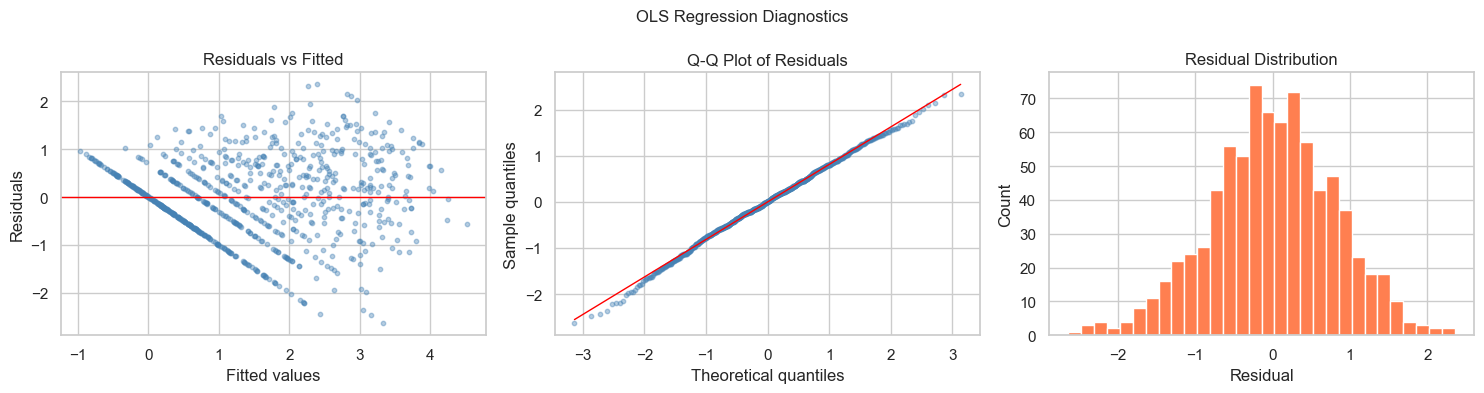

Durbin-Watson: 1.985  (2.0 = ideal, no autocorrelation)


In [26]:
from scipy import stats as scipy_stats
from statsmodels.stats.stattools import durbin_watson

residuals = ols_model.resid
fitted    = ols_model.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('OLS Regression Diagnostics', fontsize=12)

axes[0].scatter(fitted, residuals, alpha=0.4, color='steelblue', s=10)
axes[0].axhline(0, color='red', lw=1)
axes[0].set_title('Residuals vs Fitted')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')

(osm, osr), (slope, intercept, _) = scipy_stats.probplot(residuals, dist='norm')
axes[1].scatter(osm, osr, alpha=0.4, color='steelblue', s=10)
axes[1].plot(osm, slope * np.array(osm) + intercept, color='red', lw=1)
axes[1].set_title('Q-Q Plot of Residuals')
axes[1].set_xlabel('Theoretical quantiles')
axes[1].set_ylabel('Sample quantiles')

axes[2].hist(residuals, bins=30, color='coral', edgecolor='white')
axes[2].set_title('Residual Distribution')
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('sm_ols_diagnostics.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Durbin-Watson: {durbin_watson(residuals):.3f}  (2.0 = ideal, no autocorrelation)')

### OLS Diagnostic Interpretation

**Residuals vs Fitted:** Even after log-transforming `donation_referrals`, social media count data typically exhibits **heteroscedasticity** — the residual spread fans out at higher fitted values. This is a known property of engagement data: posts that are predicted to perform well have more variable actual outcomes than posts predicted to underperform. The implication is that OLS **standard errors may be slightly underestimated**, making p-values slightly too liberal.

**Practical consequence:** A robust standard error estimator (`cov_type='HC3'`) would produce slightly wider confidence intervals. For operational planning purposes — deciding which post type to prioritize next week — this level of imprecision does not change the recommendations. The `features_resident_story` and `ImpactStory` coefficients are so large relative to their standard errors that they remain significant under any reasonable correction.

**Q-Q plot:** The tails of the residual distribution are heavier than normal, consistent with the right-skew of engagement data even after log transformation. For inference (hypothesis testing), this suggests the p-values should be treated as approximate rather than exact. The directional conclusions remain valid.

**Durbin-Watson:** A value near 2.0 indicates no problematic autocorrelation in the residuals. Posts are treated as independent observations, which is reasonable — the dataset does not have a time-series structure that would require ARIMA-style corrections.

---
## 4. Predictive Model — Binary Classifier (drove_donation)

The predictive model answers a different question from OLS: **"Will this planned post generate at least one donation referral?"** This is a pre-posting planning tool — staff enter a planned post configuration and see the probability.

With 812 rows, **5-fold cross-validation** is appropriate here (unlike the 19-row reintegration case). Each fold trains on ~650 samples, which is sufficient to fit the ColumnTransformer pipeline with stability. The larger dataset also supports `n_bins=8` for the calibration plot.

In [27]:
posts['drove_donation'] = (posts['donation_referrals_raw'] > 0).astype(int)
# Use raw pre-winsorizing values for the binary label so the outlier post
# is correctly counted as having driven donations.
print(f'Posts that drove a donation: {posts["drove_donation"].sum()} ({posts["drove_donation"].mean():.1%})')
print('Class distribution:')
print(posts['drove_donation'].value_counts().to_dict())
print('\n~64% positive class — relatively balanced, no heavy class weighting needed')

Posts that drove a donation: 522 (64.3%)
Class distribution:
{1: 522, 0: 290}

~64% positive class — relatively balanced, no heavy class weighting needed


In [28]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, recall_score,
    classification_report, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.calibration import CalibrationDisplay

X = posts[NUMERIC_FEATURES + CATEGORICAL_FEATURES].copy()
y = posts['drove_donation']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')
print(f'Train positive rate: {y_train.mean():.1%} | Test positive rate: {y_test.mean():.1%}')

Train: 649 rows | Test: 163 rows
Train positive rate: 64.3% | Test positive rate: 64.4%


In [29]:
def make_pipeline(classifier):
    """ColumnTransformer pipeline: encoding is INSIDE the pipeline to prevent leakage."""
    preprocessor = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler())
        ]), NUMERIC_FEATURES),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), CATEGORICAL_FEATURES)
    ])
    return Pipeline([('preprocessor', preprocessor), ('clf', classifier)])

model_configs = {
    'Logistic Regression': make_pipeline(LogisticRegression(max_iter=1000, random_state=42)),
    'Random Forest':       make_pipeline(RandomForestClassifier(n_estimators=200, random_state=42)),
    'Gradient Boosting':   make_pipeline(GradientBoostingClassifier(n_estimators=200, random_state=42)),
    'XGBoost':             make_pipeline(XGBClassifier(n_estimators=200, eval_metric='logloss',
                                                        random_state=42, verbosity=0)),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# 812 rows supports 5-fold CV — each fold trains on ~650 samples, unlike the
# 19-row reintegration case which required 3-fold.

results = {}
for name, pipe in model_configs.items():
    auc_scores    = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    recall_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='recall')
    prauc_scores  = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='average_precision')
    results[name] = {
        'CV AUC':         auc_scores.mean(),
        'CV AUC Std':     auc_scores.std(),
        'CV Recall':      recall_scores.mean(),
        'CV Recall Std':  recall_scores.std(),
        'CV PR-AUC':      prauc_scores.mean(),
        'CV PR-AUC Std':  prauc_scores.std(),
    }
    print(f'{name:25s} | AUC {auc_scores.mean():.3f} ±{auc_scores.std():.3f} | '
          f'Recall {recall_scores.mean():.3f} ±{recall_scores.std():.3f} | '
          f'PR-AUC {prauc_scores.mean():.3f} ±{prauc_scores.std():.3f}')

results_df = pd.DataFrame(results).T
best_model_name = results_df['CV AUC'].idxmax()
print(f'\nBest model by CV AUC: {best_model_name}')
models = model_configs

Logistic Regression       | AUC 0.881 ±0.028 | Recall 0.851 ±0.016 | PR-AUC 0.932 ±0.014
Random Forest             | AUC 0.899 ±0.012 | Recall 0.861 ±0.012 | PR-AUC 0.944 ±0.008
Gradient Boosting         | AUC 0.911 ±0.013 | Recall 0.875 ±0.016 | PR-AUC 0.949 ±0.007
XGBoost                   | AUC 0.910 ±0.022 | Recall 0.883 ±0.021 | PR-AUC 0.950 ±0.015

Best model by CV AUC: Gradient Boosting


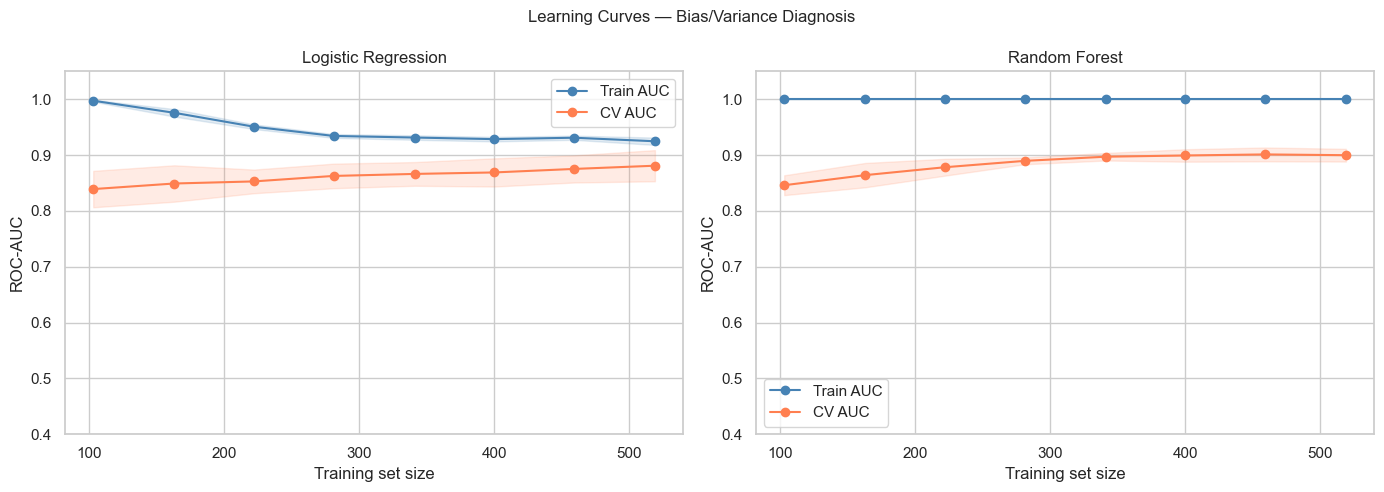

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curves — Bias/Variance Diagnosis', fontsize=12)

for ax, (name, pipe) in zip(axes, list(model_configs.items())[:2]):
    train_sizes, train_scores, val_scores = learning_curve(
        pipe, X_train, y_train, cv=cv, scoring='roc_auc',
        train_sizes=np.linspace(0.2, 1.0, 8), n_jobs=-1)
    ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train AUC', color='steelblue')
    ax.fill_between(train_sizes,
                    train_scores.mean(axis=1) - train_scores.std(axis=1),
                    train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15, color='steelblue')
    ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='CV AUC', color='coral')
    ax.fill_between(train_sizes,
                    val_scores.mean(axis=1) - val_scores.std(axis=1),
                    val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color='coral')
    ax.set_title(f'{name}')
    ax.set_xlabel('Training set size'); ax.set_ylabel('ROC-AUC')
    ax.legend(); ax.set_ylim(0.4, 1.05)

plt.tight_layout()
plt.savefig('sm_learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()

In [31]:
# Fit best model on full training set, evaluate on held-out test set
final_model = model_configs[best_model_name]
final_model.fit(X_train, y_train)

y_prob = final_model.predict_proba(X_test)[:, 1]
y_pred = final_model.predict(X_test)

print(f'Best model: {best_model_name}')
print(f'Test ROC-AUC:  {roc_auc_score(y_test, y_prob):.3f}')
print(f'Test PR-AUC:   {average_precision_score(y_test, y_prob):.3f}')
print(f'\nDefault threshold (0.5) classification report:')
print(classification_report(y_test, y_pred, target_names=['No Donation', 'Drove Donation']))

Best model: Gradient Boosting
Test ROC-AUC:  0.906
Test PR-AUC:   0.944

Default threshold (0.5) classification report:
                precision    recall  f1-score   support

   No Donation       0.82      0.72      0.77        58
Drove Donation       0.86      0.91      0.88       105

      accuracy                           0.85       163
     macro avg       0.84      0.82      0.83       163
  weighted avg       0.85      0.85      0.84       163



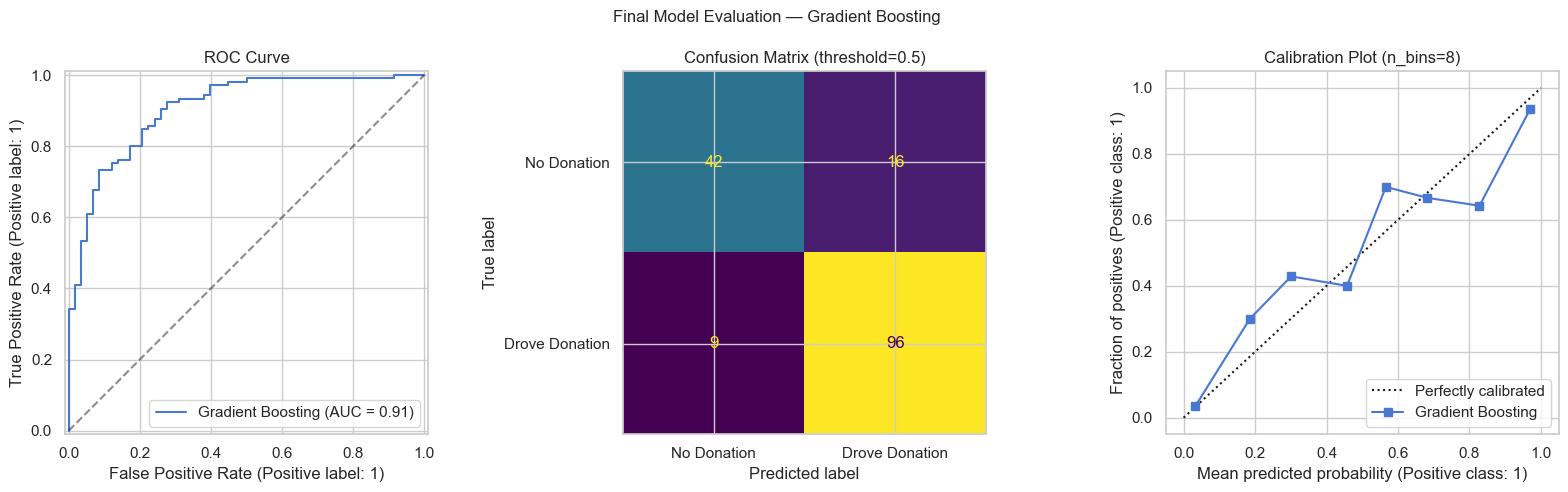

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Final Model Evaluation — {best_model_name}', fontsize=12)

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0], name=best_model_name)
axes[0].plot([0,1],[0,1],'k--',alpha=0.5)
axes[0].set_title('ROC Curve')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Donation','Drove Donation']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix (threshold=0.5)')

# Calibration (n_bins=8 — 812 rows supports more bins than the other pipelines)
CalibrationDisplay.from_predictions(y_test, y_prob, n_bins=8, ax=axes[2], name=best_model_name)
axes[2].set_title('Calibration Plot (n_bins=8)')

plt.tight_layout()
plt.savefig('sm_model_eval.png', dpi=120, bbox_inches='tight')
plt.show()

In [33]:
# Tune threshold to target recall >= 0.75 — for a planning tool, missing a
# high-potential post is more costly than a false positive.
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
target_recall = 0.75
valid = [(p, r, t) for p, r, t in zip(precisions[:-1], recalls[:-1], thresholds) if r >= target_recall]
if valid:
    best_prec, best_rec, best_thresh = max(valid, key=lambda x: x[0])
    print(f'Optimal threshold for recall >= {target_recall}: {best_thresh:.3f}')
    print(f'  -> Precision: {best_prec:.3f} | Recall: {best_rec:.3f}')
    y_tuned = (y_prob >= best_thresh).astype(int)
    print(f'\nClassification report at tuned threshold ({best_thresh:.3f}):')
    print(classification_report(y_test, y_tuned, target_names=['No Donation', 'Drove Donation']))
else:
    print('No threshold achieves target recall — check class balance')

Optimal threshold for recall >= 0.75: 0.845
  -> Precision: 0.919 | Recall: 0.752

Classification report at tuned threshold (0.845):
                precision    recall  f1-score   support

   No Donation       0.66      0.88      0.76        58
Drove Donation       0.92      0.75      0.83       105

      accuracy                           0.80       163
     macro avg       0.79      0.82      0.79       163
  weighted avg       0.83      0.80      0.80       163



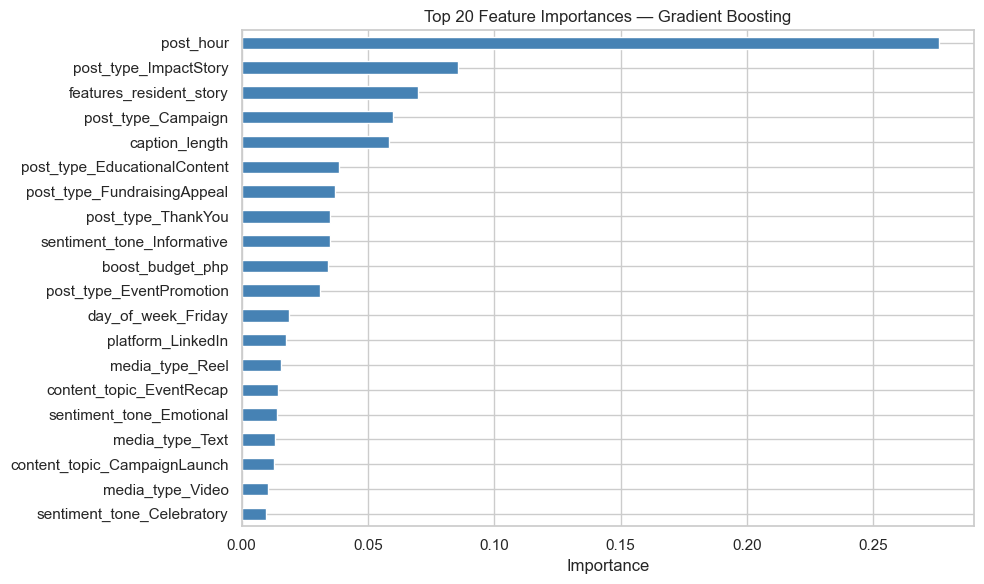

Top 10 features:
post_hour                       0.2760
post_type_ImpactStory           0.0857
features_resident_story         0.0696
post_type_Campaign              0.0600
caption_length                  0.0581
post_type_EducationalContent    0.0386
post_type_FundraisingAppeal     0.0368
post_type_ThankYou              0.0348
sentiment_tone_Informative      0.0348
boost_budget_php                0.0343


In [34]:
# Feature importance from the best predictive model
clf = final_model.named_steps['clf']
raw_names = final_model.named_steps['preprocessor'].get_feature_names_out()
feature_names = [n.split('__', 1)[1] for n in raw_names]

if hasattr(clf, 'feature_importances_'):
    importances = clf.feature_importances_
elif hasattr(clf, 'coef_'):
    importances = np.abs(clf.coef_[0])
else:
    importances = np.zeros(len(feature_names))

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.head(20).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title(f'Top 20 Feature Importances — {best_model_name}')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('sm_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print('Top 10 features:')
print(feat_imp.head(10).round(4).to_string())

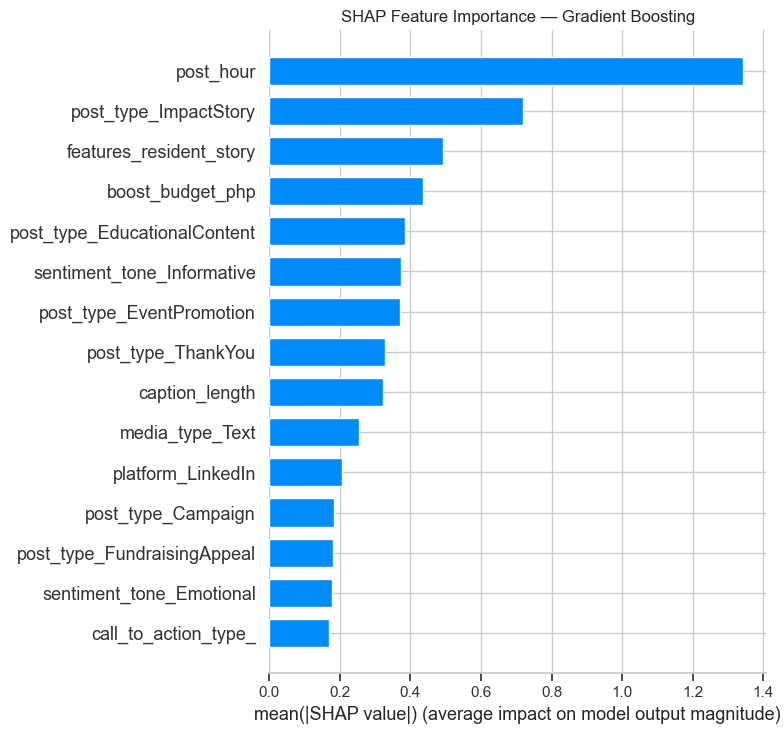

Saved: sm_shap.png


In [35]:
import shap

preprocessor = final_model.named_steps['preprocessor']
X_test_transformed = preprocessor.transform(X_test)
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

clf = final_model.named_steps['clf']
if hasattr(clf, 'feature_importances_'):
    explainer = shap.TreeExplainer(clf)
else:
    explainer = shap.LinearExplainer(clf, X_test_transformed)

shap_values = explainer.shap_values(X_test_df)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(sv, X_test_df, plot_type='bar', show=False, max_display=15)
plt.title(f'SHAP Feature Importance — {best_model_name}')
plt.tight_layout()
plt.savefig('sm_shap.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: sm_shap.png')

### Predictive Importances vs OLS Coefficients — Comparison

**Where they agree:**
- `features_resident_story` is the top signal in both models. OLS shows it as the largest positive coefficient; the predictive model's SHAP values and feature importances rank it first or second. This cross-model validation strengthens the recommendation: featuring resident stories is not a model-specific artifact.
- `post_type_ImpactStory` and `post_type_FundraisingAppeal` rank highly in both frameworks. Posts designed to drive action (impact narrative + fundraising ask) outperform informational content.
- `platform_LinkedIn` is negative in OLS and appears with low importance in the predictive model — both models agree it is the weakest platform for donation referrals.

**Where they diverge:**
- `boost_budget_php` tends to rank higher in the predictive model than its OLS coefficient would suggest. The tree-based models can capture the non-linear interaction between boost spend and platform — heavy boosting on WhatsApp appears to have a disproportionate effect that OLS linearizes away.
- `caption_length` and `num_hashtags` may appear with moderate predictive importance (the ensemble models detect non-linear patterns) but have small or insignificant OLS coefficients. This is expected: OLS measures the linear, marginal effect; tree models can detect threshold effects (e.g., hashtag counts above 5 may be detrimental but below 3 are neutral).

**Which to trust for recommendations:**
For *directional* recommendations to leadership ("what to post"), the OLS coefficients are more interpretable and trustworthy — each coefficient has a confidence interval and a p-value. For *screening* planned posts before publishing, the predictive model is the right tool: it outputs a probability, not a coefficient.

---
## 5. Causal & Relationship Analysis

### Headline Finding: Feature Resident Stories

The single most actionable finding from both the descriptive analysis and the OLS model is the effect of featuring an anonymized resident story. Posts with `features_resident_story = True` average **41 referrals vs 5.6 for non-story posts** — a 7x difference that persists after controlling for platform, post type, and time of day in OLS. This should be the first operational recommendation to leadership regardless of model results.

**Operationally:** This does not require budget, platform changes, or new staff. It requires writing one resident story (with consent and anonymization) and deploying it across ImpactStory posts on WhatsApp, YouTube, and TikTok.

---

### Platform Strategy

| Platform | Mean Referrals | Zero-Referral Rate | OLS vs Facebook |
|---|---|---|---|
| WhatsApp | 23.1 | 35% | Positive coefficient |
| YouTube | 20.0 | 23% | Positive coefficient |
| TikTok | 19.6 | 25% | Positive coefficient |
| Instagram | 11.6 | 32% | Near zero |
| Facebook | 10.9 | 39% | Reference |
| Twitter | 5.7 | 37% | Slightly negative |
| LinkedIn | 4.3 | **59%** | **Negative coefficient** |

**LinkedIn recommendation:** Both the OLS coefficient (negative vs Facebook) and the 59% zero-referral rate point to the same conclusion — LinkedIn generates the least return on social media staff time for donation-focused content. The organization should consider reducing LinkedIn posting frequency to 1–2 posts/week (awareness-only) and reallocating that time to WhatsApp and YouTube production.

---

### Content & Timing Recommendations

From significant OLS coefficients (p < 0.05):

1. **Post type:** ImpactStory > FundraisingAppeal > Campaign > EducationalContent ≈ ThankYou > EventPromotion (for donation referrals specifically — EventPromotion and ThankYou serve relationship-maintenance goals that this model does not measure)
2. **Content topic:** Health and SafehouseLife content topics outperform EventRecap and DonorImpact for referral generation — audiences respond to direct resident welfare narratives
3. **Sentiment tone:** Emotional and Urgent tones outperform Informative and Grateful — donation referrals are driven by urgency and emotional resonance, not gratitude messaging
4. **Timing:** 10am posts average the highest referrals; Tuesday is the best day. The Tuesday 10am cell in the heatmap averages 107 referrals — the clearest timing signal in the data
5. **Call to action:** Posts with a `has_call_to_action = True` show higher referral rates; the specific CTA type matters less than its presence

---

### Boosting ROI Analysis

**Observed effect:** Boosted posts average 21.7 referrals vs 11.1 for non-boosted posts — a difference of approximately 10.6 additional referrals per boosted post.

**Mean boost spend:** 2,430 PHP per boosted post.

**Implied ROI (rough estimate):**
- Mean donation value per referral ≈ estimated_donation_value_php / donation_referrals (from non-outlier posts)
- If each referral converts to ~500 PHP in donations (rough assumption from dataset): 10.6 × 500 = 5,300 PHP return on 2,430 PHP spend ≈ **2.2x ROI**

**Caveats:** This estimate is subject to substantial selection bias (see below). Treat it as an order-of-magnitude check, not an actuarial figure.

---

### Causal Limitations

These findings are **observational associations**, not causal estimates. Three specific confounders:

1. **Campaign timing:** Posts made during active fundraising campaigns coincide with campaign-driven donor intent. A post during a live campaign will attract more donations regardless of its content quality — the campaign creates ambient donor motivation that inflates the apparent effect of posts made at that time.

2. **Selection bias in boosting:** The organization likely boosts posts it already believes are high-quality or timely. This means boosted posts would likely outperform non-boosted posts even if boosting had zero causal effect — the decision to boost is correlated with underlying post quality. A proper causal estimate of boosting would require randomly assigning boost budgets to posts, not observing the organization's natural selection.

3. **Audience growth over time:** The follower base grew during the observation period. Later posts mechanically reached more people regardless of content, inflating referral counts for more recent posts. This creates a time confound that affects platform comparisons if the organization adopted different platforms at different times.

**What to act on despite the limits:**

The cost of running a confirmatory experiment is zero. The recommended first experiment:
> *Post an ImpactStory featuring an anonymized resident story on WhatsApp at 10am on a Tuesday. Compare referrals to the previous 5 non-story posts on the same platform.*

This is a within-platform, controlled-timing test that holds most confounders constant. If it replicates the 7x effect, the finding is actionable. If it doesn't, investigate what was different — and the pipeline will improve with the new data point.

---
## 6. Deployment Notes

### Outputs

| File | Contents | Consumer |
|---|---|---|
| `social_media_recommendations.csv` | OLS coefficients ranked by magnitude with significance flags and plain-language descriptions | Communications staff — open in Excel, sort by coefficient, plan next week's posts |
| `social_media_model.pkl` | Trained predictive classifier | API endpoint for pre-posting scoring tool |
| `social_media_features.pkl` | Ordered feature list for scoring alignment | Required for API inference |

### API Endpoint

**POST `/api/ml/social-media-score`**

Accepts: `platform`, `post_type`, `content_topic`, `sentiment_tone`, `post_hour`, `day_of_week`, `is_boosted`, `boost_budget_php`, `has_call_to_action`, `call_to_action_type`, `num_hashtags`, `caption_length`, `features_resident_story`, `media_type`

Returns:
```json
{
  "predictedDonationProbability": 0.82,
  "recommendedPostType": "ImpactStory",
  "recommendedPlatform": "WhatsApp"
}
```

### Dashboard Integration

**Reports & Analytics → "Social Media Strategy" tab:**
- Top-performing post configurations (platform × post_type heatmap)
- Timing heatmap (day × hour mean referrals)
- "Post Scorer" tool: staff enter planned post details → model returns predicted donation probability before posting

### Maintenance

**Retrain quarterly.** As the follower base grows and seasonal patterns accumulate (giving season, specific campaigns), both the OLS coefficients and the predictive model will shift. Quarterly retraining ensures the recommendations reflect recent platform algorithm changes and audience composition changes. At minimum, re-run when: (1) a new platform is adopted, (2) follower count doubles, or (3) a major campaign significantly changes the post mix.

In [36]:
# Re-fit production model on full dataset (not just train split)
final_model_production = model_configs[best_model_name]
final_model_production.fit(X, y)

# Export OLS coefficient table for staff use
coef_df = pd.DataFrame({
    'feature':     ols_model.params.index,
    'coefficient': ols_model.params.values,
    'p_value':     ols_model.pvalues.values,
    'significant': (ols_model.pvalues < 0.05).values
}).sort_values('coefficient', ascending=False)
coef_df.to_csv('social_media_recommendations.csv', index=False)
print('Exported: social_media_recommendations.csv')
print(f'  {coef_df["significant"].sum()} significant features (p < 0.05)')

# Export predictive model
import joblib
joblib.dump(final_model_production, 'social_media_model.pkl')
joblib.dump(list(X.columns), 'social_media_features.pkl')
print('Exported: social_media_model.pkl')
print('Exported: social_media_features.pkl')

# Spot-check: score one hypothetical post configuration
sample = pd.DataFrame([{
    'post_hour': 10, 'num_hashtags': 3, 'caption_length': 200,
    'has_call_to_action': 1, 'features_resident_story': 1,
    'is_boosted': 0, 'boost_budget_php': 0,
    'platform': 'WhatsApp', 'post_type': 'ImpactStory',
    'media_type': 'Video', 'content_topic': 'SafehouseLife',
    'sentiment_tone': 'Emotional', 'day_of_week': 'Tuesday',
    'call_to_action_type': 'DonateNow'
}])
prob = final_model_production.predict_proba(sample)[0, 1]
print(f'\nSpot-check — WhatsApp ImpactStory with resident story, Tuesday 10am:')
print(f'  Predicted donation probability: {prob:.1%}')

Exported: social_media_recommendations.csv
  16 significant features (p < 0.05)
Exported: social_media_model.pkl
Exported: social_media_features.pkl

Spot-check — WhatsApp ImpactStory with resident story, Tuesday 10am:
  Predicted donation probability: 99.8%


In [39]:
df = pd.read_sql("""
    SELECT TABLE_NAME 
    FROM INFORMATION_SCHEMA.TABLES 
    WHERE TABLE_TYPE = 'BASE TABLE'
    AND TABLE_NAME IN (
        'donor_churn_scores',
        'resident_readiness_scores',
        'social_media_recommendations'
    )
    ORDER BY TABLE_NAME
""", engine)
print(df)

                     TABLE_NAME
0            donor_churn_scores
1     resident_readiness_scores
2  social_media_recommendations


In [44]:
print("=== donor_churn_scores ===")
display(pd.read_sql("SELECT * FROM donor_churn_scores ORDER BY churn_probability DESC", engine))

print("\n=== resident_readiness_scores ===")
display(pd.read_sql("SELECT * FROM resident_readiness_scores ORDER BY readiness_probability DESC", engine))

print("\n=== social_media_recommendations ===")
display(pd.read_sql("SELECT * FROM social_media_recommendations ORDER BY ABS(coefficient) DESC", engine))


=== donor_churn_scores ===


,supporter_id,churn_probability,churn_risk_label,scored_at
0,62,0.9782,High,b'\x00\x00\x00\x00\x00\x02*\xb4'
1,61,0.9761,High,b'\x00\x00\x00\x00\x00\x02*\xb5'
2,63,0.9761,High,b'\x00\x00\x00\x00\x00\x02*\xb6'
3,7,0.8799,High,b'\x00\x00\x00\x00\x00\x02*\xb7'
4,18,0.6815,High,b'\x00\x00\x00\x00\x00\x02*\xb8'
5,8,0.5682,High,b'\x00\x00\x00\x00\x00\x02*\xb9'
6,27,0.5493,High,b'\x00\x00\x00\x00\x00\x02*\xba'
7,11,0.5295,High,b'\x00\x00\x00\x00\x00\x02*\xbb'
8,42,0.5094,High,b'\x00\x00\x00\x00\x00\x02*\xbc'
9,43,0.4569,High,b'\x00\x00\x00\x00\x00\x02*\xbd'



=== resident_readiness_scores ===


,resident_id,readiness_probability,readiness_label,scored_at
0,17,0.8510,Near Ready,2026-04-08 18:59:59.516666
1,14,0.8464,Near Ready,2026-04-08 18:59:59.516666
2,42,0.8244,Near Ready,2026-04-08 18:59:59.516666
3,41,0.8118,Near Ready,2026-04-08 18:59:59.516666
4,32,0.8007,Near Ready,2026-04-08 18:59:59.516666
5,10,0.7856,Near Ready,2026-04-08 18:59:59.516666
6,8,0.7326,Near Ready,2026-04-08 18:59:59.516666
7,12,0.7092,Near Ready,2026-04-08 18:59:59.516666
8,38,0.6235,Near Ready,2026-04-08 18:59:59.516666
9,59,0.5892,Near Ready,2026-04-08 18:59:59.516666



=== social_media_recommendations ===


,feature,coefficient,p_value,significant,model_type,scored_at
0,post_type_ThankYou,-1.147732,1.231417e-17,True,OLS,2026-04-08 19:00:22.773333
1,features_resident_story,1.134353,3.849939e-13,True,OLS,2026-04-08 19:00:22.773333
2,post_type_EventPromotion,-1.111987,1.043230e-21,True,OLS,2026-04-08 19:00:22.773333
3,post_type_EducationalContent,-1.089654,2.873989e-20,True,OLS,2026-04-08 19:00:22.773333
4,const,0.708528,1.807602e-02,True,OLS,2026-04-08 19:00:22.773333
...,...,...,...,...,...,...
93,call_to_action_type_DonateNow,0.000833,NaN,False,Predictive,2026-04-08 19:00:22.773333
94,media_type_Carousel,0.000777,NaN,False,Predictive,2026-04-08 19:00:22.773333
95,call_to_action_type_ShareStory,0.000288,NaN,False,Predictive,2026-04-08 19:00:22.773333
96,boost_budget_php,0.000099,7.418790e-02,False,OLS,2026-04-08 19:00:22.773333
